# Unemployment Analysis with Python

## Project Overview

Unemployment rate analysis helps us understand changes in employment conditions over time and across different regions. In this project, unemployment data is explored using Python to identify major trends, regional differences, and changes during the COVID-19 period.

The analysis focuses on data cleaning, exploration, visualization, and interpretation of unemployment patterns.

## Objectives

1. Analyze unemployment rates over time.
2. Compare unemployment across different regions.
3. Examine the impact of COVID-19 on unemployment.
4. Identify important trends and seasonal patterns.
5. Present key observations from the analysis.

## Technologies Used

1. Python
2. Pandas
3. NumPy
4. Matplotlib
5. Seaborn
6. Jupyter Notebook

In [2]:
import sys
sys.path.append(r"D:\Lib\site-packages")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import zipfile
with zipfile.ZipFile("unemp.zip", "r") as zip_ref:
    zip_ref.extractall()

In [6]:
df = pd.read_csv("Unemployment in India.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## Initial Data Understanding

Before cleaning and analyzing the dataset, we first examine its structure, columns, size, and basic statistics.

In [10]:
print("Dataset Shape:", df.shape)

Dataset Shape: (768, 7)


In [8]:
print("Columns:")
print(df.columns.tolist())

Columns:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']


In [9]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


## Data Quality Check

The dataset is checked for missing values and duplicate records before further analysis.

In [11]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 27


## Data Cleaning

The column names are cleaned to remove unnecessary spaces. Date values are also converted into a proper datetime format so that time-based analysis can be performed easily.

In [13]:
df.columns = df.columns.str.strip()
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df = df.drop_duplicates()
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [14]:
df.info()

<class 'pandas.DataFrame'>
Index: 741 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    str           
 1   Date                                     740 non-null    datetime64[us]
 2   Frequency                                740 non-null    str           
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    str           
dtypes: datetime64[us](1), float64(3), str(3)
memory usage: 46.3 KB


In [15]:
print("Start Date:", df["Date"].min())
print("End Date:", df["Date"].max())

Start Date: 2019-05-31 00:00:00
End Date: 2020-06-30 00:00:00


## Unemployment Rate Distribution

The distribution of unemployment rates helps us understand the range and frequency of unemployment levels in the dataset.

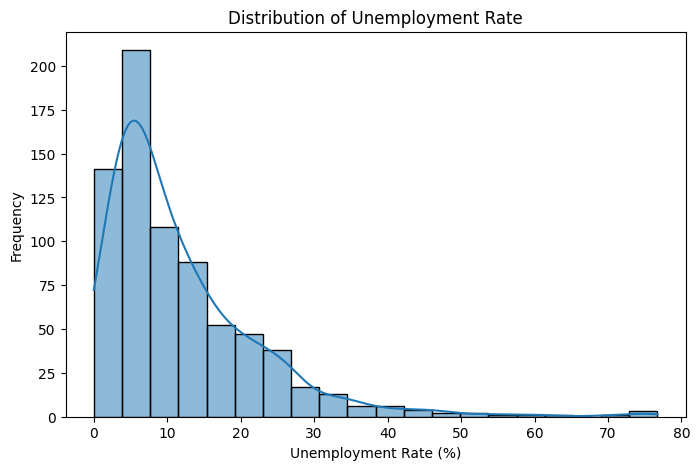

In [16]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Estimated Unemployment Rate (%)"],
    bins=20,
    kde=True
)

plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Frequency")
plt.show()

**Observation**

The unemployment rate distribution is strongly right-skewed. Most observations are concentrated between approximately 4% and 8%, where the frequency is highest. As the unemployment rate increases, the number of observations decreases considerably, with only a small number of observations reaching higher values between approximately 40% and 80%. The KDE curve also confirms the long right tail of the distribution.

## Overall Unemployment Trend

A time-series plot is used to observe how the unemployment rate changed throughout the period covered by the dataset.

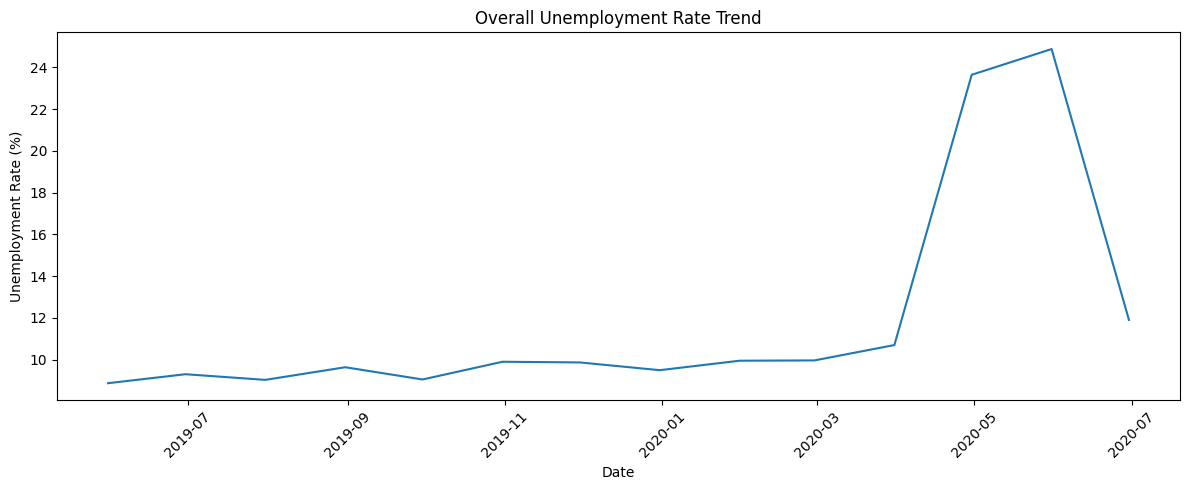

In [17]:
daily_unemployment = df.groupby("Date")[
    "Estimated Unemployment Rate (%)"
].mean().reset_index()
plt.figure(figsize=(12, 5))
plt.plot(
    daily_unemployment["Date"],
    daily_unemployment["Estimated Unemployment Rate (%)"]
)
plt.title("Overall Unemployment Rate Trend")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation**

The unemployment rate remained relatively stable at around 9%–10% from mid-2019 to March 2020. A sharp increase occurred from April 2020, with the rate rising above 23% in May and reaching approximately 25% in June. This major spike reflects the strong impact of the COVID-19 pandemic and related lockdowns on employment. By July 2020, the unemployment rate dropped considerably to around 12%, indicating an initial improvement in employment conditions.

## Regional Unemployment Comparison

Unemployment rates are compared across different regions using their average unemployment rate. This provides a clearer view of regional differences in unemployment during the study period.

In [18]:
regional_unemployment = df.groupby("Region")[
    "Estimated Unemployment Rate (%)"
].mean().sort_values(ascending=False)
regional_unemployment

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

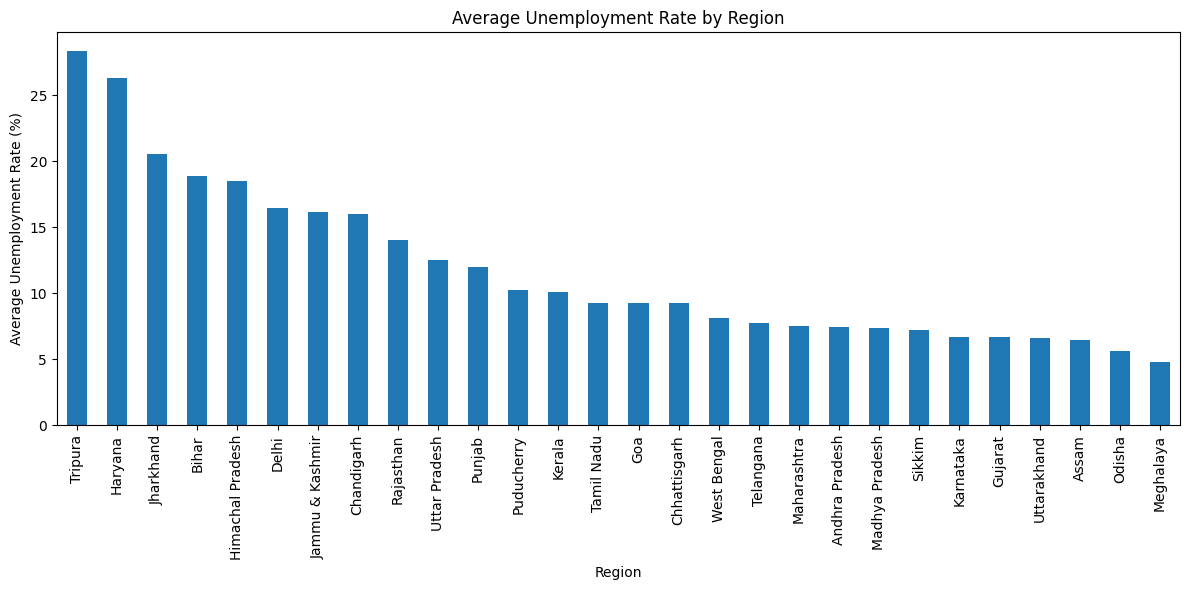

In [19]:
plt.figure(figsize=(12, 6))
regional_unemployment.plot(kind="bar")
plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Observation**

The average unemployment rate varies considerably across regions. Tripura and Haryana have the highest average unemployment rates, both exceeding 25%, followed by Jharkhand and Bihar. In comparison, Punjab, Kerala, and Tamil Nadu show moderate average unemployment rates of around 10%–12.5%. Meghalaya has the lowest average unemployment rate at below 5%, while Odisha and Assam are also among the regions with lower rates.

## Monthly Unemployment Pattern

To identify monthly patterns, the unemployment rate is grouped by month and the average rate for each month is calculated. This helps reveal whether unemployment tends to vary across different months.

In [20]:
df["Month"] = df["Date"].dt.month
monthly_unemployment = df.groupby("Month")[
    "Estimated Unemployment Rate (%)"
].mean()
print(monthly_unemployment)

Month
1.0      9.950755
2.0      9.964717
3.0     10.700577
4.0     23.641569
5.0     16.646190
6.0     10.553462
7.0      9.033889
8.0      9.637925
9.0      9.051731
10.0     9.900909
11.0     9.868364
12.0     9.497358
Name: Estimated Unemployment Rate (%), dtype: float64


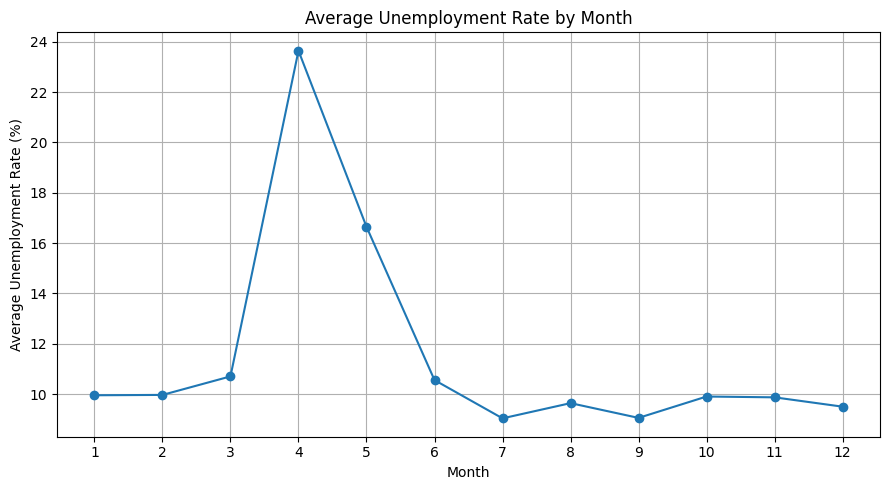

In [21]:
plt.figure(figsize=(9, 5))
monthly_unemployment.plot(kind="line", marker="o")
plt.title("Average Unemployment Rate by Month")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()

**Observation**

The monthly unemployment pattern remains relatively stable from January to March, with rates around 9%–11%. A sharp increase occurs in April, when the average unemployment rate rises to nearly 24%. The rate then falls to approximately 16.5% in May and returns closer to the earlier level by June. This pattern highlights the major disruption in unemployment during the COVID-19 period, followed by an initial recovery.

## COVID-19 Impact Analysis

The COVID-19 pandemic caused major disruptions to employment conditions. To examine its impact, unemployment rates before and during the pandemic are compared using the available data.

The analysis focuses on the period around 2020, when the unemployment rate experienced a significant increase.

In [22]:
before_covid = df[df["Date"] < "2020-03-01"][
    "Estimated Unemployment Rate (%)"
].mean()
during_covid = df[
    (df["Date"] >= "2020-03-01") &
    (df["Date"] <= "2020-07-31")
]["Estimated Unemployment Rate (%)"].mean()
print("Average Unemployment Rate Before COVID-19:",
      round(before_covid, 2), "%")
print("Average Unemployment Rate During COVID-19:",
      round(during_covid, 2), "%")

Average Unemployment Rate Before COVID-19: 9.51 %
Average Unemployment Rate During COVID-19: 17.77 %


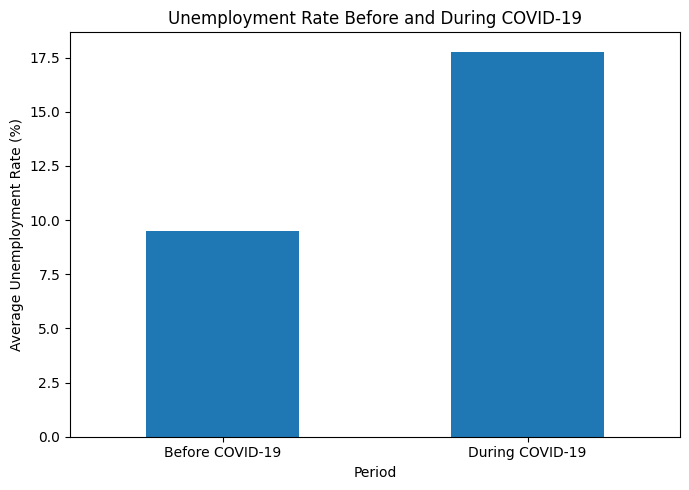

In [23]:
covid_comparison = pd.Series(
    [before_covid, during_covid],
    index=["Before COVID-19", "During COVID-19"]
)
plt.figure(figsize=(7, 5))
covid_comparison.plot(kind="bar")
plt.title("Unemployment Rate Before and During COVID-19")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation**

The average unemployment rate was approximately 9.5% before COVID-19, but increased to around 17.8% during the COVID-19 period. This represents a substantial rise in unemployment, highlighting the major disruption to employment conditions during the pandemic.

## Key Findings

The analysis of unemployment data reveals several important patterns:

1. Unemployment remained relatively stable before COVID-19, at around 9%–10%.
2. A sharp increase occurred during the COVID-19 period, with the average rate rising from approximately 9.5% to 17.8%.
3. April and May 2020 show particularly high unemployment levels.
4. Unemployment rates differ considerably across regions, indicating unequal employment conditions.
5. The monthly analysis shows a clear disruption around the COVID-19 period followed by an initial decline in unemployment.

## Final Conclusion

The analysis shows that unemployment was relatively stable before COVID-19 but increased substantially during the pandemic. The strongest increase occurred around April and May 2020, while unemployment also varied considerably across regions. Overall, the analysis demonstrates how data analysis and visualization can be used to identify major changes and patterns in employment conditions.
